In [1]:
import os
import glob
import sys
import dill
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from yaml import safe_load, YAMLError, dump
from tabulate import tabulate
from scipy.interpolate import RectBivariateSpline
from scipy.stats import norm

import config as cfg 
import post_bdtlh_efficiency_finder as eff_finder
import bdt_lh_cut_opt_with_n_interp as opt
plt.style.use('fcc.mplstyle')

In [2]:
save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/'

with open(os.path.join(opt.set_outputpath(save_path), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

with open(os.path.join(opt.set_outputpath(save_path), "N_remaining_dictionary"), "rb") as dill_file:
    N_dict = dill.load(dill_file)

In [3]:
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF = opt.run_2d_optimisation(interp_N_dict,lrange_plot=(0.995,1) ,hrange_plot=(0.995,1), nlh=500 , sig_BF=1e-6, incl_ZqqBFerror = False)

Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       168.757 |               0.9996 |               0.9996 |
+---------------+----------------------+----------------------+


In [4]:
indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]
print(l_cut)

0.9996492985971944


In [5]:
#Load dataframe with bdtlh version applied
data={}
dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.samples:
    data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)

#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus

(array([[ 37.,  75.],
       [ 17., 103.]]), array([0.99962926, 0.99981463, 1.        ]), array([0.9996493 , 0.99982465, 1.        ]), <matplotlib.collections.QuadMesh object at 0x7f3cd8c8a8c0>)


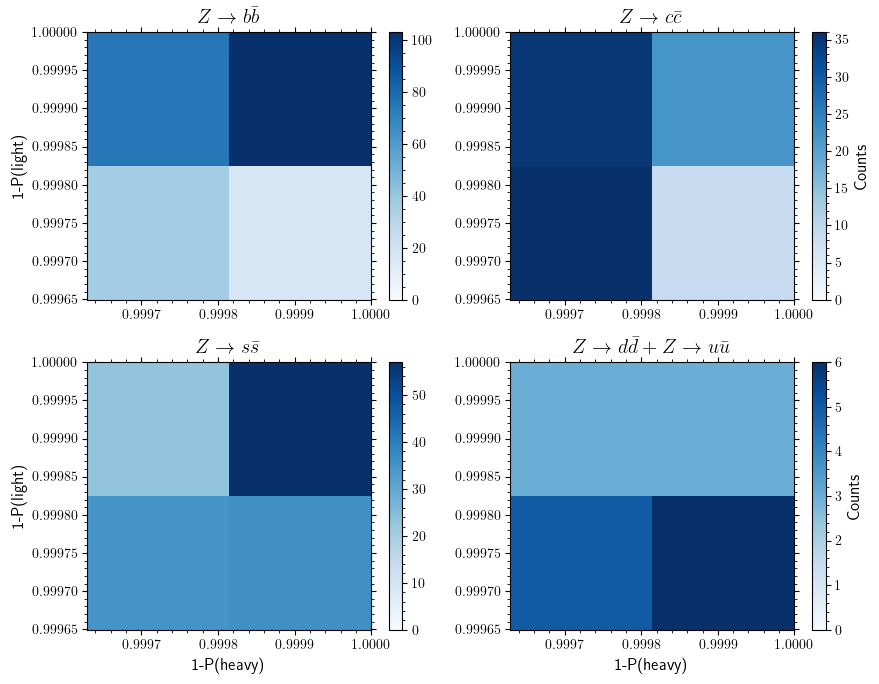

In [6]:
cut_data = full_data.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

df_bb = cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91']
df_cc = cut_data[cut_data['decay']=='p8_ee_Zcc_ecm91']
df_ss = cut_data[cut_data['decay']=='p8_ee_Zss_ecm91']
df_ud = cut_data[cut_data['decay']=='p8_ee_Zud_ecm91']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title(cfg.titles['p8_ee_Zbb_ecm91'])
axs[0,0].set_ylabel('1-P(light)')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title(cfg.titles['p8_ee_Zcc_ecm91'])
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title(cfg.titles['p8_ee_Zss_ecm91'])
axs[1,0].set_xlabel('1-P(heavy)')
axs[1,0].set_ylabel('1-P(light)')


axs[1, 1].set_title(cfg.titles['p8_ee_Zud_ecm91'])
axs[1,1].set_xlabel('1-P(heavy)')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb["P_not_heavy"], df_bb["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
h2 = axs[0, 1].hist2d(df_cc["P_not_heavy"], df_cc["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
h3 = axs[1, 0].hist2d(df_ss["P_not_heavy"], df_ss["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
h4 = axs[1, 1].hist2d(df_ud["P_not_heavy"], df_ud["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1], label='Counts')
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1], label='Counts')

print(h1)


plt.show()

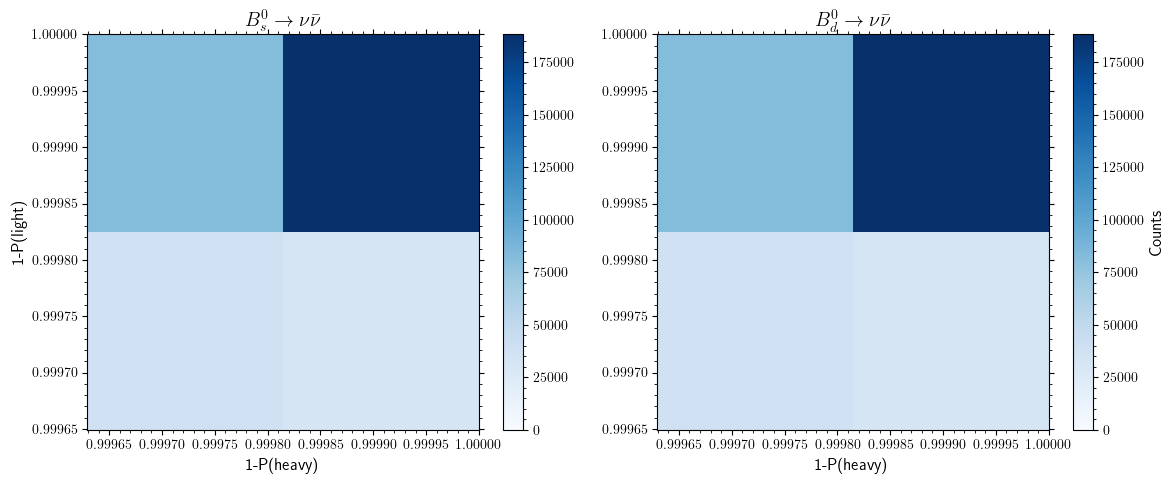

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
df_Bs=  cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']
df_Bd=  cut_data[cut_data['decay']=='p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu']
# Big bins
h=axs[0].hist2d(df_Bs["P_not_heavy"], df_Bs["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False, range = [[h_cut, 1], [l_cut, 1]])
h1=axs[1].hist2d(df_Bs["P_not_heavy"], df_Bs["P_not_light"], bins=(2, 2), cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
axs[0].set_title(cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'])
axs[1].set_title(cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
axs[0].set_ylabel('1-P(light)')
axs[0].set_xlabel('1-P(heavy)')
axs[1].set_xlabel('1-P(heavy)')

# Visualizing colorbar 
fig.colorbar(h[3], ax=axs[0])
fig.colorbar(h1[3], ax=axs[1],label='Counts')
plt.show()

In [8]:
for decay in cfg.sample_allocations['leptonic_background']:
    df = cut_data[cut_data['decay']== decay]
    print(decay)
    print(len(df))

p8_ee_Ztautau_ecm91
0
p8_ee_Zmumu_ecm91
0
p8_ee_Zee_ecm91
0


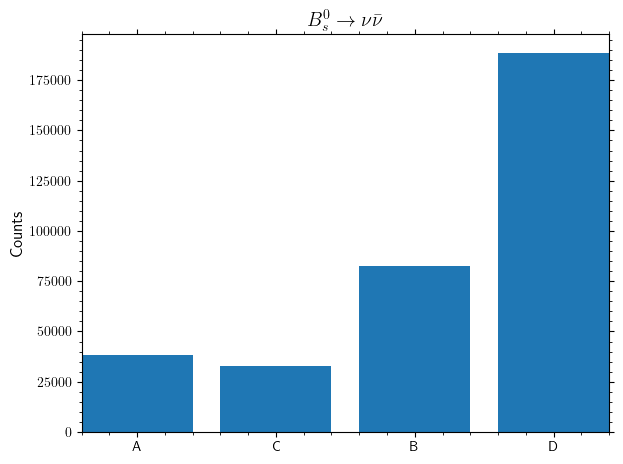

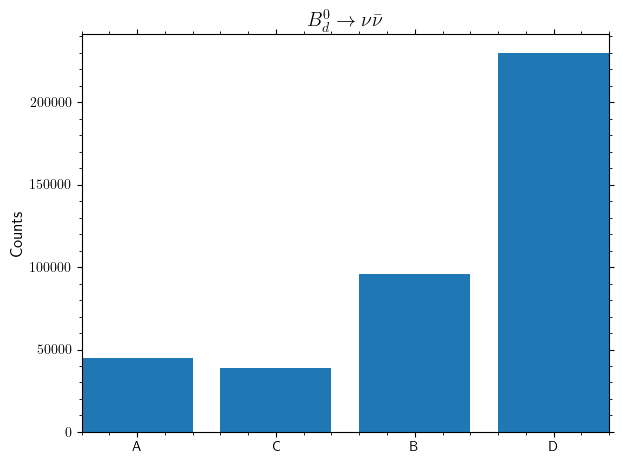

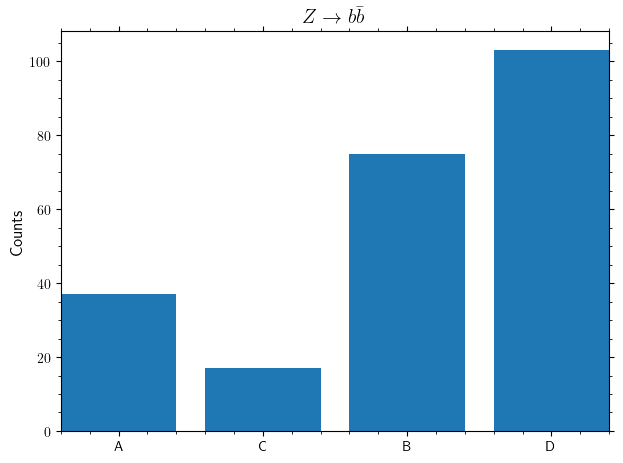

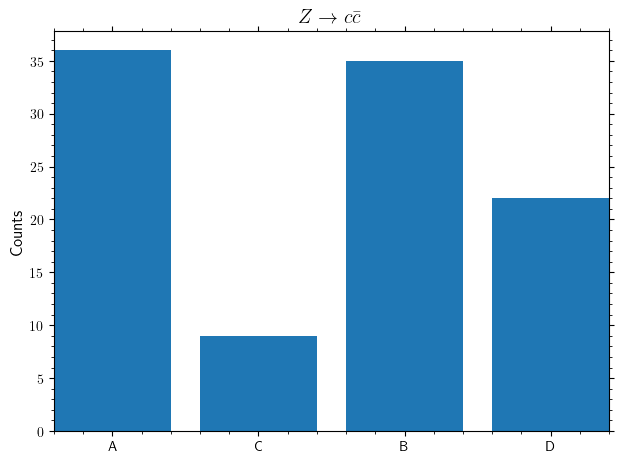

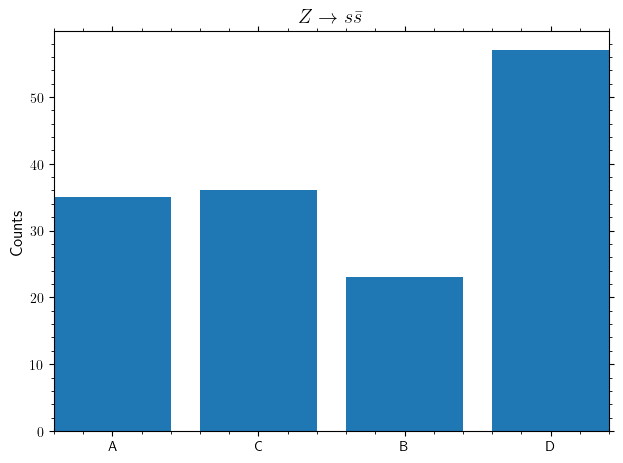

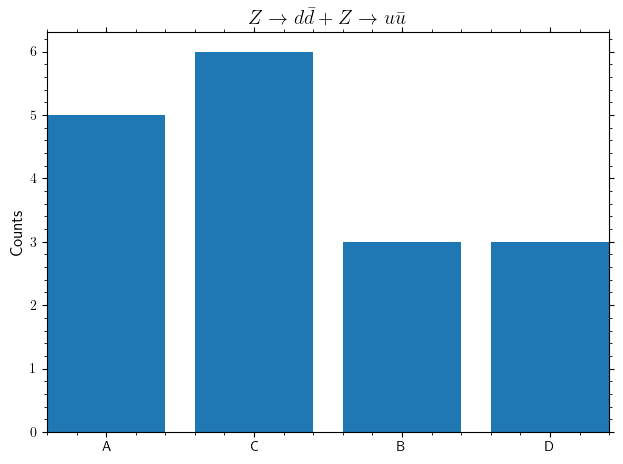

In [9]:
signal_bf = 1e-6

for decay in cfg.sample_allocations['combined_signal']:
    df = cut_data[cut_data['decay']== decay]
    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, range=[[h_cut, 1], [l_cut, 1]], density=False)
    #print(h)
    #print(h[0].flatten())
    #print(np.array([['A','B'],['C','D']]).flatten())
    x = np.array([['A','B'],['C','D']])
    plt.bar([x[0,0],x[1,0],x[0,1],x[1,1]],[h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]])
    plt.title(cfg.titles[decay])
    plt.ylabel('Counts')
    plt.show()
   

for decay in cfg.sample_allocations['hadronic_background']:
    df = cut_data[cut_data['decay']== decay]
    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]])
    #print(h)
    #print(h[0].flatten())
    #print(np.array([['A','B'],['C','D']]).flatten())
    x = np.array([['A','B'],['C','D']])
    plt.bar([x[0,0],x[1,0],x[0,1],x[1,1]],[h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]])
    plt.title(cfg.titles[decay])
    plt.ylabel('Counts')
    plt.show()
    

n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=29781.706752000002


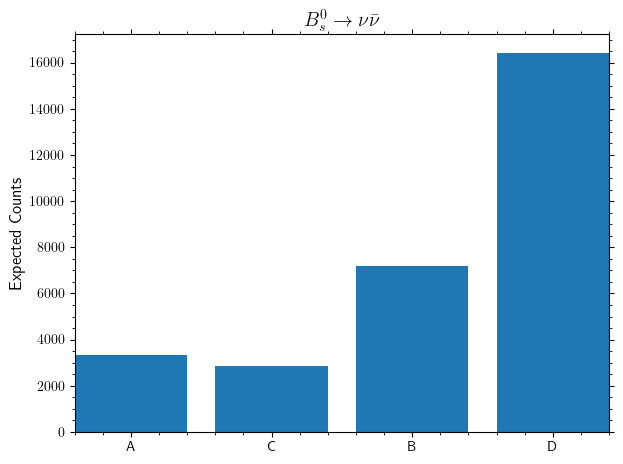

n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=144875.2710109091


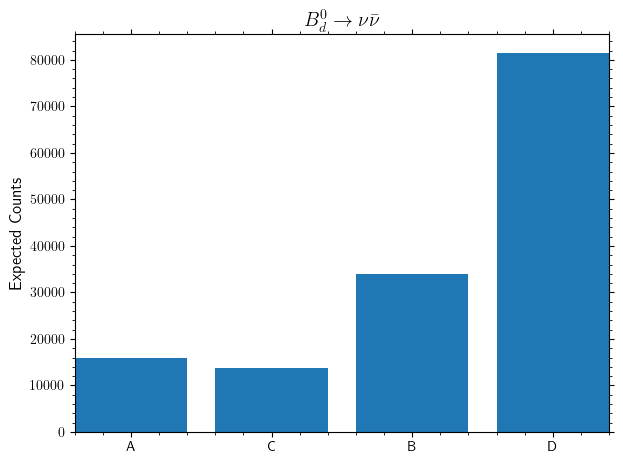

n_p8_ee_Zbb_ecm91=479717.0393725775


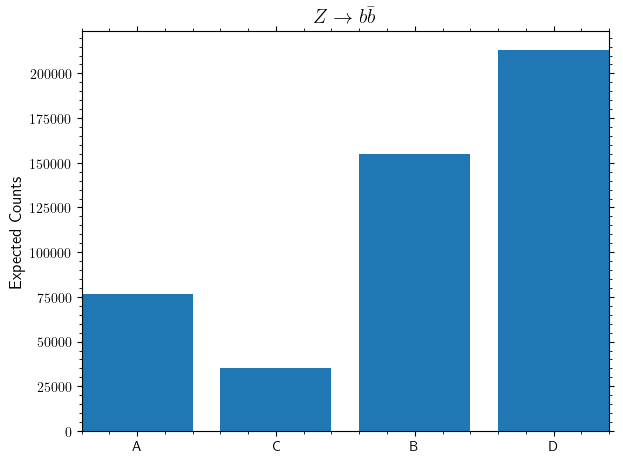

n_p8_ee_Zcc_ecm91=147310.1028870338


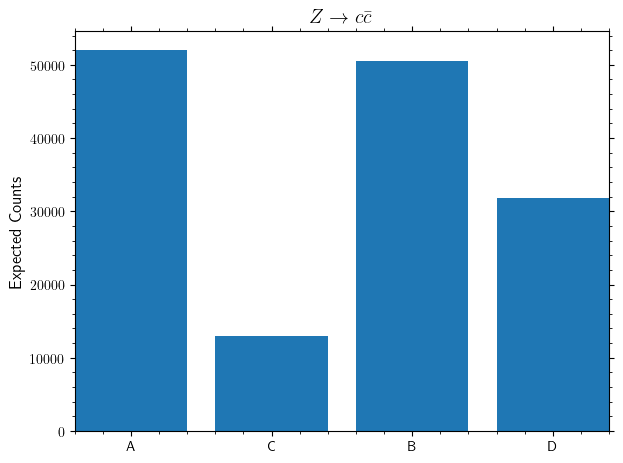

n_p8_ee_Zss_ecm91=287120.7984316778


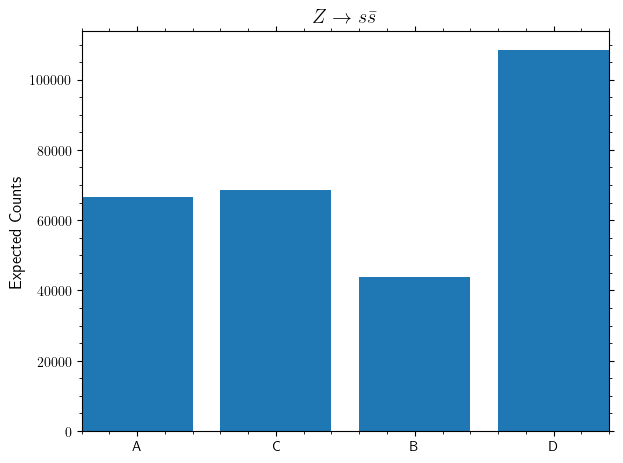

n_p8_ee_Zud_ecm91=55327.13724769753


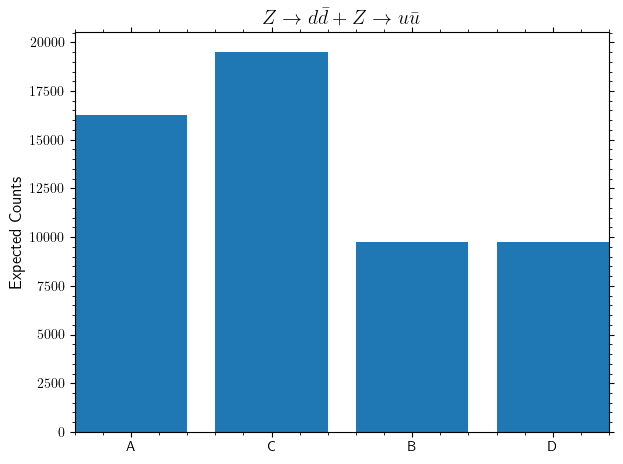

In [10]:
signal_bf = 1e-6

for decay in cfg.sample_allocations['combined_signal']:
    df = cut_data[cut_data['decay']== decay]
    
    #calculate weight
    eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
    n_exp, n_err= eff_finder.get_n_expected(eff, err, signal_bf=signal_bf)
    hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
    print(f'n_{decay}={n_exp[decay]}' )

    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, range=[[h_cut, 1], [l_cut, 1]], density=False, weights=hist_w )
    #print(h)
    #print(h[0].flatten())
    #print(np.array([['A','B'],['C','D']]).flatten())
    x = np.array([['A','B'],['C','D']])
    plt.bar([x[0,0],x[1,0],x[0,1],x[1,1]],[h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]])
    plt.title(cfg.titles[decay])
    plt.ylabel('Expected Counts')
    plt.show()
   

for decay in cfg.sample_allocations['hadronic_background']:
    
    df = cut_data[cut_data['decay']== decay]
    
    #calculate weight
    eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
    n_exp, n_err = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf)
    hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
    print(f'n_{decay}={n_exp[decay]}' )

    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]],  weights=hist_w )

    x = np.array([['A','B'],['C','D']])
    plt.bar([x[0,0],x[1,0],x[0,1],x[1,1]],[h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]])
    plt.title(cfg.titles[decay])
    plt.ylabel('Expected Counts')
    plt.show()
    

**nb Errors complete nonsense here - see error_investigation_final_binning_plot for corrected errors**

p8_ee_Zbb_ecm91
0.06579454044092639
n_p8_ee_Zbb_ecm91=479717.0393725775
p8_ee_Zcc_ecm91
0.099498926162192
n_p8_ee_Zcc_ecm91=147310.1028870338
p8_ee_Zss_ecm91
0.08164785476581024
n_p8_ee_Zss_ecm91=287120.7984316778
p8_ee_Zud_ecm91
0.2495670934786479
n_p8_ee_Zud_ecm91=55327.13724769753
dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91'])
n_p8_ee_Zud_ecm91=55327.13724769753
0.04711571511026764
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
0.0015570223827375154
n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=29781.706752000002
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
0.0014118437523427667
n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=144875.2710109091



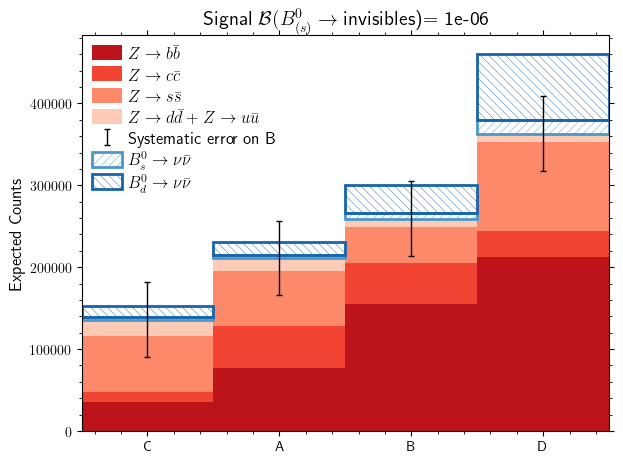

In [21]:
signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]
allocation = 'hadronic_background'
i=0
tot_arr = [0,0,0,0]
samples =cfg.sample_allocations['hadronic_background']
for decay in samples:
    df = cut_data[cut_data['decay']== decay]
    #calculate weight
    eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
    print(decay)
    print(err[decay]/eff[decay])
    n_exp, n_err = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf,calc_BFZbb_err = False)
    
    n_exp_arr.append(n_exp[decay])
    n_exp_err_arr.append(n_err[decay])
    hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
    print(f'n_{decay}={n_exp[decay]}' )

    color = plt.cm.Reds_r( np.linspace(0, 1, len(samples)+2)[1:-1] )[i]
    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]],  weights=hist_w)

    x = np.array([['A','B'],['C','D']])
    plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],[h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]],label=cfg.titles[decay],color=color, bottom=tot_arr, width=1.0)
    tot_arr =  [sum(x) for x in zip(tot_arr, [h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]])]
    i+=1
    

### for error calculation including BF(Z->qq) error in systematic###########################
df = cut_data[cut_data['decay'].isin(samples)]
#calculate weight
eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
n_expect_dict, n_err_dict, BFZbb_err_dict_components = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf,calc_BFZbb_err = True)
print(f'n_{decay}={n_exp[decay]}' )

B_height = sum(n_expect_dict[decay] for decay in samples)
B_var = sum(n_err_dict[decay]**2 for decay in samples)
B_var_incl_BF_unc = B_var +  BFZbb_err_dict_components['hadronic_background']**2          
B_err = np.sqrt(B_var_incl_BF_unc)
print(B_err/B_height)
plt.errorbar([x[1,0],x[0,0],x[0,1],x[1,1]],tot_arr, B_err,label='Systematic error on B',  fmt='None', ecolor='black')
#plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],2*B_err,label='Systematic error on B',color='k',alpha = 0.2, bottom=tot_arr-B_err, width=1.0)
################################################################################################

i=0
sig_samples = cfg.sample_allocations['combined_signal']
hatching = ['////',r'\\\\']
for decay in sig_samples:
    df = cut_data[cut_data['decay']== decay]
    #calculate weight
    eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
    print(decay)
    print(err[decay]/eff[decay])
    n_exp, n_err = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf)
    n_exp_arr.append(n_exp[decay])
    n_exp_err_arr.append(n_err[decay])
    hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
    print(f'n_{decay}={n_exp[decay]}' )

    color =  plt.cm.Blues( np.linspace(0, 1, len(sig_samples)+4)[3:-1] )[i]
    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]],  weights=hist_w)

    x = np.array([['A','B'],['C','D']])
    plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],[h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]],label=cfg.titles[decay],edgecolor=color, bottom=tot_arr,hatch = hatching[i], facecolor='none',alpha=1,lw=2, width=1.0)
    tot_arr =  [sum(x) for x in zip(tot_arr, [h[0][1,0],h[0][0,0],h[0][0,1],h[0][1,1]])]
    i+=1

S_var = sum(n_exp_err_arr[i]**2 for i in [4,5])
S_err = np.sqrt(S_var)

#plt.errorbar([x[1,0],x[0,0],x[0,1],x[1,1]],tot_arr, S_err,label='Systematic error on S',  fmt='None', ecolor='darkblue')

plt.title(r'Signal $\mathcal{B}(B^0_{(s)}\rightarrow{}$invisibles)$=$ '+ f'{signal_bf}')
plt.legend()
plt.ylabel('Expected Counts')


print()

n_p8_ee_Zbb_ecm91=479717.0393725775
n_p8_ee_Zcc_ecm91=147310.1028870338
n_p8_ee_Zss_ecm91=287120.7984316778
n_p8_ee_Zud_ecm91=55327.13724769753
frac B err 0.045563930989350535
n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=29781.706752000002
n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=144875.2710109091


Text(0, 0.5, 'Expected Counts')

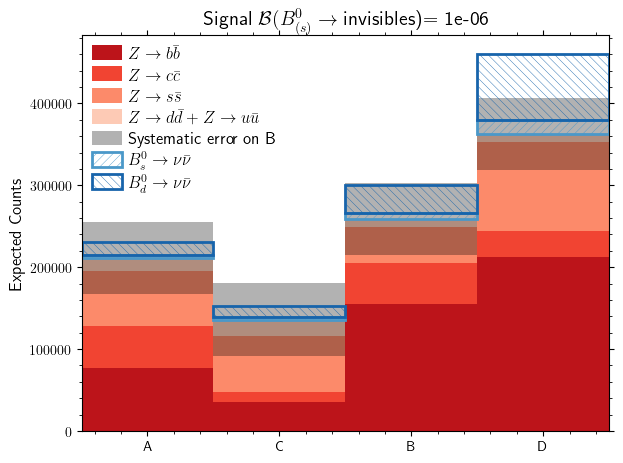

In [18]:
signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]
allocation = 'hadronic_background'
i=0
tot_arr = [0,0,0,0]
samples =cfg.sample_allocations['hadronic_background']
for decay in samples:
    df = cut_data[cut_data['decay']== decay]
    #calculate weight
    eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
    n_exp, n_err = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf)
    
    n_exp_arr.append(n_exp[decay])
    n_exp_err_arr.append(n_err[decay])
    hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
    print(f'n_{decay}={n_exp[decay]}' )

    color = plt.cm.Reds_r( np.linspace(0, 1, len(samples)+2)[1:-1] )[i]
    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]],  weights=hist_w)

    x = np.array([['A','B'],['C','D']])
    plt.bar([x[0,0],x[1,0],x[0,1],x[1,1]],[h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]],label=cfg.titles[decay],color=color, bottom=tot_arr, width=1.0)
    tot_arr =  [sum(x) for x in zip(tot_arr, [h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]])]
    i+=1

B_var = sum(n_exp_err_arr[i]**2 for i in range(len(n_exp_err_arr)))
B_err = np.sqrt(B_var)

print(f'frac B err {B_err/sum(n_exp_arr)}')

plt.bar([x[0,0],x[1,0],x[0,1],x[1,1]],2*B_err,label='Systematic error on B',color='k',alpha = 0.3, bottom=tot_arr-B_err, width=1.0) #excludes Zqq BF systematic
#plt.errorbar([x[0,0],x[1,0],x[0,1],x[1,1]],tot_arr, B_err,  fmt='None', ecolor='black')
i=0
sig_samples = cfg.sample_allocations['combined_signal']
hatching = ['////',r'\\\\']
for decay in sig_samples:
    df = cut_data[cut_data['decay']== decay]
    #calculate weight
    eff, err, N_remaining= eff_finder.get_total_eff_post_bdt(df, cut=None, verbose=False) #already filtered df on cut earlier
    n_exp, n_err = eff_finder.get_n_expected(eff, err, signal_bf=signal_bf)
    n_exp_arr.append(n_exp[decay])
    hist_w = n_exp[decay]/len(df[df['decay']==decay])* np.ones_like(np.array(df['P_not_heavy'])) 
    print(f'n_{decay}={n_exp[decay]}' )

    color =  plt.cm.Blues( np.linspace(0, 1, len(sig_samples)+4)[3:-1] )[i]
    h = np.histogram2d(df["P_not_heavy"], df["P_not_light"], bins=2, density=False, range = [[h_cut, 1], [l_cut, 1]],  weights=hist_w)

    x = np.array([['A','B'],['C','D']])
    plt.bar([x[0,0],x[1,0],x[0,1],x[1,1]],[h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]],label=cfg.titles[decay],edgecolor=color, bottom=tot_arr,hatch = hatching[i], facecolor='none',alpha=1,lw=2, width=1.0)
    tot_arr =  [sum(x) for x in zip(tot_arr, [h[0][0,0],h[0][1,0],h[0][0,1],h[0][1,1]])]
    i+=1

plt.title(r'Signal $\mathcal{B}(B^0_{(s)}\rightarrow{}$invisibles)$=$ '+ f'{signal_bf}')
plt.legend()
plt.ylabel('Expected Counts')


    

In [13]:
n_exp_arr

[479717.0393725775,
 147310.1028870338,
 287120.7984316778,
 55327.13724769753,
 29781.706752000002,
 144875.2710109091]

In [14]:
B = sum([n_exp_arr[i] for i in [0,1,2,3]])
S = sum([n_exp_arr[i] for i in [4,5]])

In [15]:
S/np.sqrt(S+B)

163.2855916175404